Load Clean Data and Split

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# 1. Load the CLEANED data from Notebook 1
df = pd.read_csv('processed_sleep_data.csv')

In [3]:
# 2. Split into Features (X) and Target (y)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

In [4]:
# 3. Split into Train (80%) and Test (20%)
# stratify=y keeps the same ratio of disorders in training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Class names mapping from the previous notebook's encoder
class_names = ['Insomnia', 'None', 'Sleep Apnea'] 
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (299, 12)
Testing data shape: (75, 12)


Logistic Regression

In [6]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred_lr = log_reg.predict(X_test)

In [8]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.86      0.80      0.83        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.92        75
   macro avg       0.89      0.90      0.89        75
weighted avg       0.92      0.92      0.92        75



KNN

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
y_pred_knn = knn.predict(X_test)

In [11]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=class_names))

Accuracy: 0.9067

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.76      0.87      0.81        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.87      0.88      0.87        75
weighted avg       0.91      0.91      0.91        75



Visualizing KNN

In [12]:
# Generate a Confusion Matrix to put in the PDF report
cm = confusion_matrix(y_test, y_pred_knn)

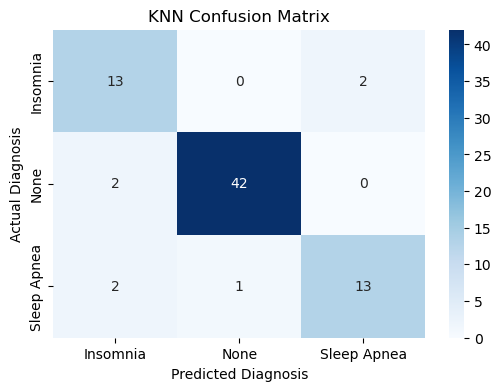

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()